In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, log_loss
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.isotonic import IsotonicRegression


features = pd.read_csv("../data/customer_features_lowie1.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [20]:
# churn target
df["returned"] = (df["revenue_2018_2019"] > 0).astype(int)

In [21]:
X = df.drop(columns=["cust_id", "revenue_2018_2019", "returned"])
y = df["returned"]

In [22]:
X_trainval, X_val, y_trainval, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)
print(f"Train: {len(X_train)}  Cal: {len(X_cal)}  Val: {len(X_val)}")

Train: 69954  Cal: 23318  Val: 23319


# LightGBM

In [23]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "num_leaves": [32, 64, 128],
    "min_child_samples": [20, 30, 50],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

search_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, n_jobs=1),
    param_distributions=lgb_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)
search_lgb.fit(X_train, y_train)

print("Best params:", search_lgb.best_params_)
print("Best AUC:", search_lgb.best_score_)

lgb_model = search_lgb.best_estimator_
lgb_model.set_params(n_jobs=-1)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 17067, number of negative: 29569
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11206
[LightGBM] [Info] Number of data points in the train set: 46636, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365962 -> initscore=-0.549580
[LightGBM] [Info] Start training from score -0.549580
[LightGBM] [Info] Number of positive: 17067, number of negative: 29569
[LightGBM] [Info] Number of positive: 17067, number of negative: 29569
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025926 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11190
[LightGBM] [Info] Number of data point

,boosting_type,'gbdt'
,num_leaves,32
,max_depth,-1
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [24]:
p_val_lgb = lgb_model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, p_val_lgb)
ll = log_loss(y_val, p_val_lgb)

print("AUC:", auc)
print("Log loss:", ll)

AUC: 0.7250714212276343
Log loss: 0.5999050207825786


In [25]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
9,avg_size,1116
48,brand_return_rate,1027
16,revenue_recency_ratio,601
0,total_revenue,453
15,frequency_recency_ratio,415
1,max_item_revenue,404
21,weighted_orders,381
47,recency_x_revenue,360
40,size_std_x_orders,349
39,recency_x_frequency,348


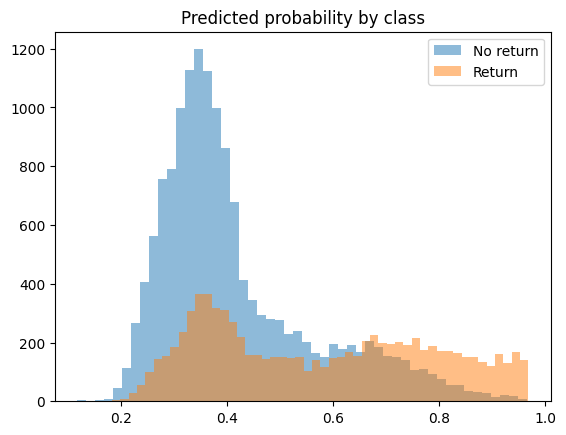

In [26]:
plt.hist(p_val_lgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_lgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# XGBoost

In [27]:
xgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}

search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric="logloss", n_jobs=1),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=8
)
search_xgb.fit(X_train, y_train)

print("Best params:", search_xgb.best_params_)
print("Best AUC:", search_xgb.best_score_)

xgb_model = search_xgb.best_estimator_
xgb_model.set_params(n_jobs=8)
xgb_model.fit(X_train, y_train)

p_val_xgb = xgb_model.predict_proba(X_val)[:,1]

print("XGBoost AUC:", roc_auc_score(y_val, p_val_xgb))
print("XGBoost LogLoss:", log_loss(y_val, p_val_xgb))

/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:48:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:48:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:48:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:48:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_en

Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
Best AUC: 0.7243582896300077


/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:49:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.725338443149634
XGBoost LogLoss: 0.5998398061008462


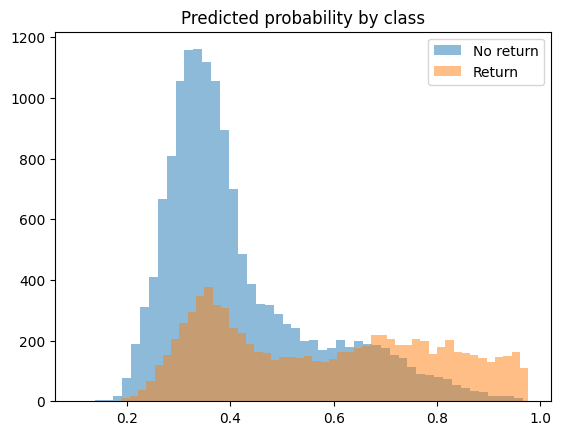

In [28]:
plt.hist(p_val_xgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_xgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# CatBoost

In [29]:
cat_param_grid = {
    "iterations": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bylevel": [0.7, 0.8, 0.9],
    "min_child_samples": [20, 30, 50]
}

search_cat = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, scale_pos_weight=scale_pos_weight, loss_function="Logloss", verbose=False, thread_count=1),
    param_distributions=cat_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=8
)
search_cat.fit(X_train, y_train)

print("Best params:", search_cat.best_params_)
print("Best AUC:", search_cat.best_score_)

best_cat_params = search_cat.best_params_
cat_model = CatBoostClassifier(
    **best_cat_params,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    loss_function="Logloss",
    verbose=False,
    thread_count=8
)
cat_model.fit(X_train, y_train)

p_val_cat = cat_model.predict_proba(X_val)[:,1]

print("CatBoost AUC:", roc_auc_score(y_val, p_val_cat))
print("CatBoost LogLoss:", log_loss(y_val, p_val_cat))

/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.9, 'min_child_samples': 30, 'learning_rate': 0.05, 'iterations': 500, 'depth': 4, 'colsample_bylevel': 0.8}
Best AUC: 0.7236680522681672
CatBoost AUC: 0.7246295995805884
CatBoost LogLoss: 0.6000631725333686


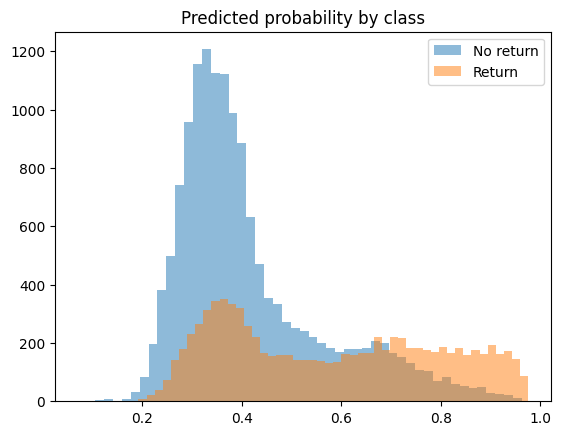

In [30]:
plt.hist(p_val_cat[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_cat[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# random forest

In [31]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=20,
    class_weight="balanced",  # equivalent van scale_pos_weight
    random_state=42,
    n_jobs=8
)
rf_clf.fit(X_train, y_train)

p_val_rf = rf_clf.predict_proba(X_val)[:, 1]
print("Random Forest AUC:", roc_auc_score(y_val, p_val_rf))
print("Random Forest LogLoss:", log_loss(y_val, p_val_rf))

Random Forest AUC: 0.7183163759255635
Random Forest LogLoss: 0.5956841083346208


# Comparison

In [32]:
results = {
    "LightGBM":     roc_auc_score(y_val, p_val_lgb),
    "XGBoost":      roc_auc_score(y_val, p_val_xgb),
    "CatBoost":     roc_auc_score(y_val, p_val_cat),
    "RandomForest": roc_auc_score(y_val, p_val_rf),
}
print("Individual model AUCs:")
for name, auc in results.items():
    print(f"  {name}: {auc:.4f}")

p_val_ensemble = (p_val_lgb + p_val_xgb + p_val_cat + p_val_rf) / 4
ensemble_auc = roc_auc_score(y_val, p_val_ensemble)
ensemble_ll  = log_loss(y_val, p_val_ensemble)
print(f"\nEnsemble (avg) AUC:      {ensemble_auc:.4f}")
print(f"Ensemble (avg) Log Loss: {ensemble_ll:.4f}")

Individual model AUCs:
  LightGBM: 0.7251
  XGBoost: 0.7253
  CatBoost: 0.7246
  RandomForest: 0.7183

Ensemble (avg) AUC:      0.7250
Ensemble (avg) Log Loss: 0.5977


In [33]:
# Kansen op calibratieset
p_cal_lgb = lgb_model.predict_proba(X_cal)[:, 1]
p_cal_xgb = xgb_model.predict_proba(X_cal)[:, 1]
p_cal_cat = cat_model.predict_proba(X_cal)[:, 1]
p_cal_rf  = rf_clf.predict_proba(X_cal)[:, 1]

# Fit calibrators
iso_lgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_lgb, y_cal)
iso_xgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_xgb, y_cal)
iso_cat = IsotonicRegression(out_of_bounds="clip").fit(p_cal_cat, y_cal)
iso_rf  = IsotonicRegression(out_of_bounds="clip").fit(p_cal_rf,  y_cal)

# Gecalibreerde kansen op validatieset
p_val_lgb_cal = iso_lgb.transform(lgb_model.predict_proba(X_val)[:, 1])
p_val_xgb_cal = iso_xgb.transform(xgb_model.predict_proba(X_val)[:, 1])
p_val_cat_cal = iso_cat.transform(cat_model.predict_proba(X_val)[:, 1])
p_val_rf_cal  = iso_rf.transform(rf_clf.predict_proba(X_val)[:, 1])
p_val_ensemble_cal = (p_val_lgb_cal + p_val_xgb_cal + p_val_cat_cal + p_val_rf_cal) / 4

print(f"Gecalibreerde ensemble AUC: {roc_auc_score(y_val, p_val_ensemble_cal):.4f}")
print(f"Gemiddelde gecalibreerde kans: {p_val_ensemble_cal.mean():.4f}")
print(f"Werkelijke fractie returners: {y_val.mean():.4f}")

Gecalibreerde ensemble AUC: 0.7247
Gemiddelde gecalibreerde kans: 0.3649
Werkelijke fractie returners: 0.3667


# Save Models

In [34]:
import os
os.makedirs("../models", exist_ok=True)


In [35]:
feature_cols = X.columns.tolist()

In [36]:
joblib.dump(lgb_model, "../models/lowie1_churn_lgb_model.pkl")
joblib.dump(xgb_model, "../models/lowie1_churn_xgb_model.pkl")
joblib.dump(cat_model, "../models/lowie1_churn_cat_model.pkl")
joblib.dump(rf_clf, "../models/lowie1_churn_rf_model.pkl")
joblib.dump(feature_cols, "../models/lowie1_feature_columns.pkl")

joblib.dump(iso_lgb, "../models/lowie1_iso_lgb.pkl")
joblib.dump(iso_xgb, "../models/lowie1_iso_xgb.pkl")
joblib.dump(iso_cat, "../models/lowie1_iso_cat.pkl")
joblib.dump(iso_rf,  "../models/lowie1_iso_rf.pkl")

['../models/lowie1_iso_rf.pkl']